In [1]:
import nltk
nltk.download("punkt")        # 문장·단어 토큰화용
nltk.download("stopwords")    # 불용어(의미 없는 단어) 목록

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\it\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\it\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [3]:
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

text = "Data science is fun. Data is the new oil and data drives decisions."
tokens = [w.lower() for w in word_tokenize(text) if w.isalpha()]  # 소문자+단어만
stop = set(stopwords.words("english"))
words = [w for w in tokens if w not in stop]                      # 불용어 제거

count = Counter(words)
print(count.most_common(5))    # [('data', 3), ('fun', 1), ...]

[('data', 3), ('science', 1), ('fun', 1), ('new', 1), ('oil', 1)]


In [4]:
from konlpy.tag import Okt
from collections import Counter

okt = Okt()
message = "빅데이터 분석은 재미있다. 데이터 분석으로 인사이트를 얻는다."
nouns = okt.nouns(message)          # 명사만 추출: ['빅데이터','분석','데이터',...]
nouns = [w for w in nouns if len(w) > 1]   # 한 글자 단어 제거
count = Counter(nouns)
print(count.most_common(10))

[('분석', 2), ('빅데이터', 1), ('데이터', 1), ('인사이트', 1)]


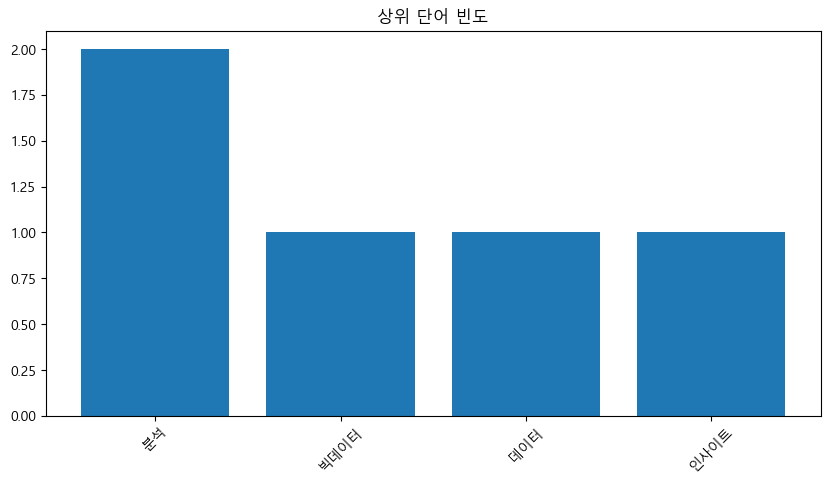

In [5]:
import matplotlib.pyplot as plt
import platform
plt.rc("font", family="AppleGothic" if platform.system()=="Darwin" else "Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

top = count.most_common(10)
words_, counts_ = zip(*top)
plt.figure(figsize=(10, 5))
plt.bar(words_, counts_)
plt.title("상위 단어 빈도"); plt.xticks(rotation=45); plt.show()

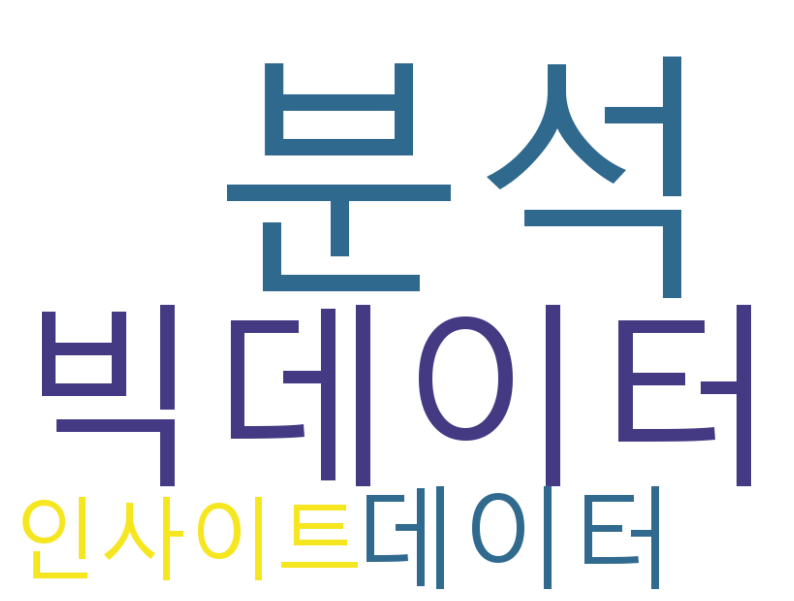

In [7]:
from wordcloud import WordCloud

# 한글은 한글 폰트 경로를 font_path로 지정해야 글자가 안 깨짐
font = "C:/Windows/Fonts/malgun.ttf"  # macOS 예시(Win: C:/Windows/Fonts/malgun.ttf)
wc = WordCloud(font_path=font, background_color="white", width=800, height=600)
wc.generate_from_frequencies(dict(count))   # {단어: 빈도} 딕셔너리 입력

plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off"); plt.show()
wc.to_file("wordcloud.png")   # 이미지로 저장